In [3]:
from python_speech_features import *
import numpy as np
import scipy.io.wavfile
from matplotlib import pyplot as plt
import os

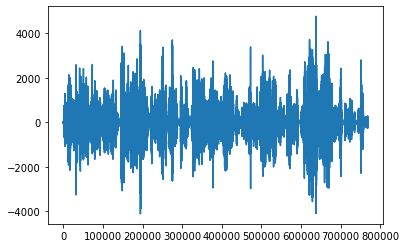

<class 'numpy.ndarray'>
(57576, 39)


In [5]:
class WavtoMfcc(object):

    def __init__(self, ul, num_wav, numc=13):

        self.numc = numc
        self.ul = ul
        self.num_wav = num_wav

    def get_mfcc(self, data, fs):

        wav_feature = mfcc(data, fs, numcep=self.numc, winlen=0.025, winstep=0.01,
                           nfilt=26, nfft=512, lowfreq=0, highfreq=None, preemph=0.97)
        '''
        signal - 需要用来计算特征的音频信号，应该是一个N*1的数组
        samplerate - 我们用来工作的信号的采样率
        winlen - 分析窗口的长度，按秒计，默认0.025s(25ms)
        winstep - 连续窗口之间的步长，按秒计，默认0.01s（10ms）
        numcep - 倒频谱返回的数量，默认13
        nfilt - 滤波器组的滤波器数量，默认26
        nfft - FFT的大小，默认512
        lowfreq - 梅尔滤波器的最低边缘，单位赫兹，默认为0
        highfreq - 梅尔滤波器的最高边缘，单位赫兹，默认为采样率/2
        preemph - 应用预加重过滤器和预加重过滤器的系数，0表示没有过滤器，默认0.97
        ceplifter - 将升降器应用于最终的倒谱系数。 0没有升降机。默认值为22。
        appendEnergy - 如果是true，则将第0个倒谱系数替换为总帧能量的对数。 
        '''
        d_mfcc_feat = delta(wav_feature, 1)
        d_mfcc_feat2 = delta(wav_feature, 2)
        feature = np.hstack((wav_feature, d_mfcc_feat, d_mfcc_feat2))
        return feature

    def readwav(self):
        total_mfcc = []
        total_num, numk = [], []
        m1 = 0
        count=0
        filenames=os.listdir(self.ul)
        for i in filenames:
            count+=1
            if count==self.numc:
                break
            sample_rate, signal = scipy.io.wavfile.read(self.ul +'/'+ i)
            mfcck = self.get_mfcc(signal, sample_rate)
            m, n = mfcck.shape
            total_mfcc.extend(mfcck)
            m1 = m1 + m
            numk.append(m)
            total_num.append(m1)
        total_mfcc = np.array(total_mfcc)
        plt.figure()
        plt.plot(signal)
        plt.show()
        
       
        return total_mfcc, total_num


if __name__ == '__main__':
    cur_path=os.getcwd()
    ul = os.path.join(cur_path,'split_data','test','AD')
    k = 1  # 读取音频数量
    mfccdim = 13  # mfcc基本维数
    getmfcc = WavtoMfcc(ul, k, mfccdim)
    mfcc, numk = getmfcc.readwav()
    print(type(mfcc))
    print(mfcc.shape)

In [4]:
import python_speech_features

<ipython-input-8-b1c3b42866b0>:8: RuntimeWarning: invalid value encountered in log
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
<ipython-input-8-b1c3b42866b0>:13: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(X, Y, log_spec)


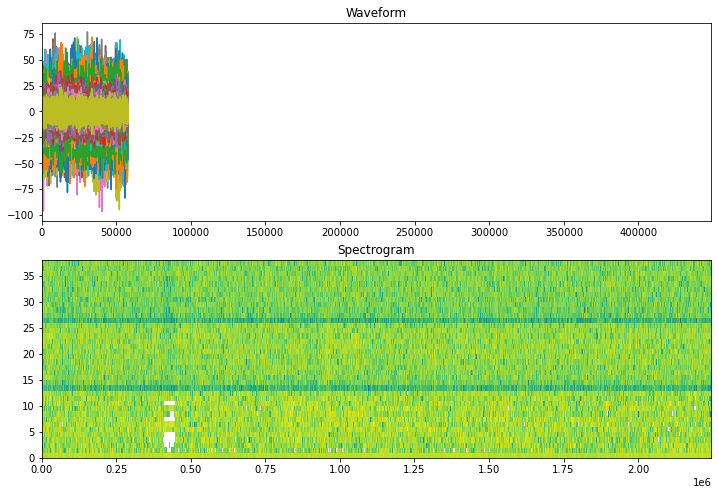

In [9]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(mfcc.shape[0])
axes[0].plot(timescale,mfcc)
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 448800])

plot_spectrogram(mfcc, axes[1])
axes[1].set_title('Spectrogram')
plt.show()

In [7]:
def get_spectrogram(waveform):
  # Zero-padding for an audio waveform with less than 16,000 samples.
    input_len = 16000
    waveform = waveform[:input_len]
    zero_padding = tf.zeros(
      [16000] - tf.shape(waveform),
      dtype=tf.float32)
  # Cast the waveform tensors' dtype to float32.
    waveform = tf.cast(waveform, dtype=tf.float32)
  # Concatenate the waveform with `zero_padding`, which ensures all audio
  # clips are of the same length.
    equal_length = tf.concat([waveform, zero_padding], 0)
  # Convert the waveform to a spectrogram via a STFT.
    spectrogram = tf.signal.stft(
      equal_length, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
    spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
    spectrogram = spectrogram[..., tf.newaxis]
    return spectrogram

In [8]:
def plot_spectrogram(spectrogram, ax):
    if len(spectrogram.shape) > 2:
        assert len(spectrogram.shape) == 3
        spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
    log_spec = np.log(spectrogram.T + np.finfo(float).eps)
    height = log_spec.shape[0]
    width = log_spec.shape[1]
    X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
    Y = range(height)
    ax.pcolormesh(X, Y, log_spec)

<ipython-input-30-b1c3b42866b0>:8: RuntimeWarning: invalid value encountered in log
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
<ipython-input-30-b1c3b42866b0>:13: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(X, Y, log_spec)


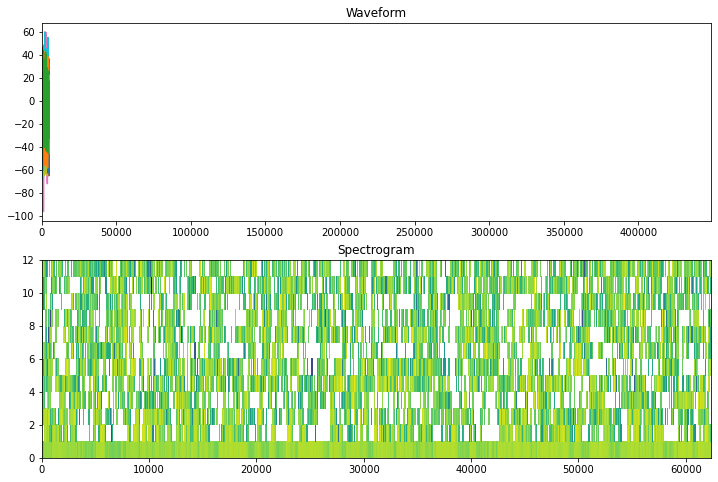

In [33]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(processed_audio.shape[0])
axes[0].plot(timescale, processed_audio)
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 448800])

plot_spectrogram(processed_audio, axes[1])
axes[1].set_title('Spectrogram')
plt.show()

In [35]:
import librosa
librosa.feature.

<module 'librosa.feature' from 'D:\\anaconda\\lib\\site-packages\\librosa\\feature\\__init__.py'>

In [11]:
import numpy as np
import wave
import matplotlib.pyplot as plt
import librosa
import os

(1, 2, 16000, 767840)


<ipython-input-16-1a1c1c05f3aa>:11: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  signal =np.fromstring(str_data,dtype=np.int16)#将字符串转换为int类型的数组，我的sampwidth为2，所以转换为int16


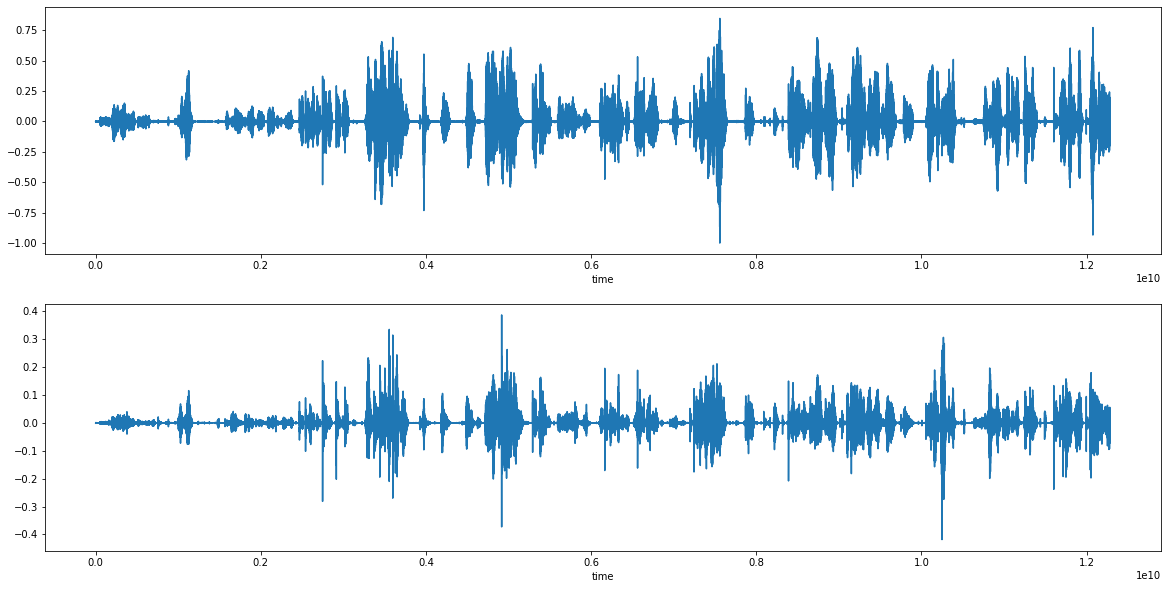

In [16]:
cur_path=os.getcwd()
ul = os.path.join(cur_path,'split_data','test','AD')
filenames=os.listdir(ul)
path=os.path.join(ul,filenames[0])

f = wave.open(path,"rb")#将.wav放在pycharm工程目录下,rb为只读
params = f.getparams()
nchannels, sampwidth, framerate, nframes =params[:4]
print(params[:4])#返回声道数、量化位数、采样频率、采样点数
str_data = f.readframes(nframes)#readframes返回的是字符串类型的数据
signal =np.fromstring(str_data,dtype=np.int16)#将字符串转换为int类型的数组，我的sampwidth为2，所以转换为int16
signal_len=len(signal)
signal=signal/(max(abs(signal)))#归一化
#------预加重并画时域波形----------

signal_add=np.append(signal[0],signal[1:]-0.97*signal[:-1])   
time=np.arange(0,nframes)/1.0*framerate #画时间轴
plt.figure(figsize=(20,10))
plt.subplot(2,1,1)
plt.plot(time[0:len(signal)],signal)#可能出现时间轴和信号长度不相等的情况，我这里选取了与singala长度相等的time
plt.xlabel('time')
plt.subplot(2,1,2)
plt.plot(time[0:len(signal_add)],signal_add)
plt.xlabel('time')
plt.show()

#----分帧------

wlen=400#每帧信号的帧数
inc=160#帧移
N=200#每帧信号帧数的一半
nf = int(np.ceil((1.0 * signal_len - wlen +
inc) / inc))#计算帧数nf
pad_len=int((nf-1)*inc+wlen)
zeros=np.zeros(pad_len-signal_len)#不够的点用0填补
pad_signal=np.concatenate((signal,zeros))
indices=np.tile(np.arange(0,wlen),(nf,1))+np.tile(np.arange(0,nf*inc,inc),(wlen,1)).T
indices=np.array(indices,dtype=np.int32)
frames=pad_signal[indices]#最终得到帧数*帧长形式的信号数据
win=np.hamming(wlen)#先调用窗函数
x=frames[10:] #我选取其中某一帧的数据提取PLP系数，即为frames的某一行
y=win*x[0]#得到加窗后的信号


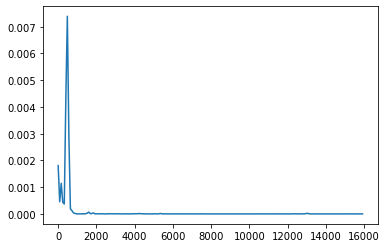

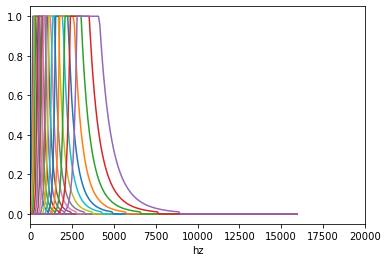

In [18]:
#all-----先定义了两个公式，bark_change为线性频率坐标转换为Bark坐标，equal_loudness为等响度曲线--------
def bark_change(x):
    return 6*np.log10(x/(1200*np.pi)+((x/(1200*np.pi))**2+1)**0.5)
def equal_loudness(x):   
    return ((x**2+56.8e6)*x**4)/((x**2+6.3e6)**2*(x**2+3.8e8))
a=np.fft.fft(y)#做fft，默认为信号的长度即1024点
b=np.square(abs(a[0:N])) #求fft变换结果的模的平方，只取a的一半
df=framerate/N  #频率分辨率
i=np.arange(N)#只取大于0部分的频率
freq_hz=i*df#得到实际频率坐标
plt.plot(freq_hz,b)#得到该帧信号的功率谱
plt.show()
freq_w=2*np.pi*np.array(freq_hz)#转换为角频率
freq_bark=bark_change(freq_w)#再转换为bark频率
point_hz= [250, 350, 450, 570, 700, 840,1000, 1170, 1370, 1600, 1850, 2150,2500,2900,3400]
#选取的临界频带数量一般要大于10，覆盖常用频率范围，这里我选取了15个中心频点
point_w=2*np.pi*np.array(point_hz)#转换为角频率
point_bark =bark_change(point_w)#转换为bark频率
bank=np.zeros((15,N))#构造15行512列的矩阵，每一行为一个滤波器向量
filter_data=np.zeros(15)#构造15维频带能量向量
#-------构造滤波器组，这一段注意缩进---------
for j in range(15):   
    for k in range(N):     
        omg= freq_bark[k]- point_bark[j]       
        if -1.3<omg<-0.5:
            bank[j,k]=10**(2.5*(omg+0.5))       
        elif -0.5<omg<0.5:           
            bank[j,k]=1     
        elif 0.5<omg<2.5:           
            bank[j,k] = 10**(-1.0*(omg-0.5))       
        else:           
            bank[j,k]=0   
    filter_data[j] = np.sum(b * bank[j]) #滤波后将该段信号相加，最终得到15维的频带能量     
    plt.plot(freq_hz,bank[j])
    plt.xlim(0,20000)   
    plt.xlabel('hz')
plt.show()#画滤波器组


In [20]:
equal_data=equal_loudness(point_w)*filter_data
cubic_data=equal_data**0.33
#---做30点的ifft，得到30维PLP向量------------
plp_data=np.fft.ifft(cubic_data,30)
print(plp_data)
plp_data.shape

[ 0.02690849+0.00000000e+00j  0.00794963+1.59326494e-02j
  0.00334536+6.17233658e-03j  0.00097372+9.81220064e-03j
 -0.00294286+3.76424532e-03j -0.00184566+2.52280311e-03j
 -0.00079272-8.48201855e-04j  0.00119655+1.28955245e-03j
  0.00021632-3.37056674e-05j  0.00144272+1.44818306e-03j
 -0.00018686+3.02271161e-04j  0.0012026 +8.37050999e-04j
 -0.00020358+1.59063162e-04j  0.00114864+3.71444099e-04j
 -0.00016971-4.27753520e-05j  0.00130398+9.25185854e-19j
 -0.00016971+4.27753520e-05j  0.00114864-3.71444099e-04j
 -0.00020358-1.59063162e-04j  0.0012026 -8.37050999e-04j
 -0.00018686-3.02271161e-04j  0.00144272-1.44818306e-03j
  0.00021632+3.37056674e-05j  0.00119655-1.28955245e-03j
 -0.00079272+8.48201855e-04j -0.00184566-2.52280311e-03j
 -0.00294286-3.76424532e-03j  0.00097372-9.81220064e-03j
  0.00334536-6.17233658e-03j  0.00794963-1.59326494e-02j]


(30,)

<ipython-input-28-63526ad08214>:22: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  signal =np.fromstring(str_data,dtype=np.int16)#将字符串转换为int类型的数组，我的sampwidth为2，所以转换为int16


(2997, 1024)


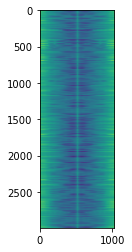

array([[ 7.15565611,  7.14617907,  7.11805396, ...,  7.07216999,
         7.11805396,  7.14617907],
       [ 6.37805169,  6.36900776,  6.34215514, ...,  6.2983062 ,
         6.34215514,  6.36900776],
       [ 7.55383655,  7.54670362,  7.5254808 , ...,  7.49068333,
         7.5254808 ,  7.54670362],
       ...,
       [10.91034874, 10.90780818, 10.90022287, ..., 10.88770069,
        10.90022287, 10.90780818],
       [10.38209433, 10.38483011, 10.39300091, ..., 10.40649634,
        10.39300091, 10.38483011],
       [ 9.95580672,  9.95743808,  9.96229696, ...,  9.97027757,
         9.96229696,  9.95743808]])

In [28]:
import numpy as np
import wave
# import matplotlib.pyplot as plt
import librosa

cur_path=os.getcwd()
ul = os.path.join(cur_path,'split_data','test','AD')
filenames=os.listdir(ul)
filename=os.path.join(ul,filenames[0])
# -----先定义了两个公式，bark_change为线性频率坐标转换为Bark坐标，equal_loudness为等响度曲线--------
def bark_change(x):
    return 6*np.log10(x/(1200*np.pi)+((x/(1200*np.pi))**2+1)**0.5)
def equal_loudness(x):
    return ((x**2+56.8e6)*x**4)/((x**2+6.3e6)**2*(x**2+3.8e8))

def get_plp_lpc(filename):
    f = wave.open(filename,"rb")#将.wav放在pycharm工程目录下,rb为只读
    params = f.getparams()
    nchannels, sampwidth, framerate, nframes =params[:4]
    # print(params[:4])#返回声道数、量化位数、采样频率、采样点数
    str_data = f.readframes(nframes)#readframes返回的是字符串类型的数据
    signal =np.fromstring(str_data,dtype=np.int16)#将字符串转换为int类型的数组，我的sampwidth为2，所以转换为int16
    signal_len=len(signal)
    signal=signal/(max(abs(signal)))#归一化
    # ------预加重并画时域波形----------
    # signal_add=np.append(signal[0],signal[1:]-0.97*signal[:-1])
    # time=np.arange(0,nframes)/1.0*framerate #画时间轴
    # plt.figure(figsize=(20,10))
    # plt.subplot(2,1,1)
    # plt.plot(time[0:len(signal)],signal)#可能出现时间轴和信号长度不相等的情况，我这里选取了与singala长度相等的time
    # plt.xlabel('time')
    # plt.subplot(2,1,2)
    # plt.plot(time[0:len(signal_add)],signal_add)
    # plt.xlabel('time')
    # plt.show()
    #


    # ----分帧------
    wlen=1024#每帧信号的帧数
    inc=256#帧移
    # N=512#每帧信号帧数的一半
    N=1024#每帧信号帧数的一半
    nf = int(np.ceil((1.0 * signal_len - wlen +
    inc) / inc))#计算帧数nf
    pad_len=int((nf-1)*inc+wlen)
    zeros=np.zeros(pad_len-signal_len)#不够的点用0填补
    pad_signal=np.concatenate((signal,zeros))
    indices=np.tile(np.arange(0,wlen),(nf,1))+np.tile(np.arange(0,nf*inc,inc),(wlen,1)).T
    indices=np.array(indices,dtype=np.int32)
    frames=pad_signal[indices]#最终得到帧数*帧长形式的信号数据
    win=np.hamming(wlen)#先调用窗函数
    # x=frames[10:] #我选取其中某一帧的数据提取PLP系数，即为frames的某一行
    # y=win*x[0]#得到加窗后的信号
    y=win*frames




    # a=np.fft.fft(y)#做fft，默认为信号的长度即1024点
    # b=np.square(abs(a[0:N])) #求fft变换结果的模的平方，只取a的一半
    b=np.square(abs(np.fft.fft(y)))
    df=framerate/N  #频率分辨率
    i=np.arange(N)#只取大于0部分的频率
    freq_hz=i*df#得到实际频率坐标
    # plt.plot(freq_hz,b)#得到该帧信号的功率谱
    # plt.show()
    freq_w=2*np.pi*np.array(freq_hz)#转换为角频率
    freq_bark=bark_change(freq_w)#再转换为bark频率
    point_hz= [250, 350, 450, 570, 700, 840,1000, 1170, 1370, 1600, 1850, 2150,2500,2900,3400]
    #选取的临界频带数量一般要大于10，覆盖常用频率范围，这里我选取了15个中心频点
    point_w=2*np.pi*np.array(point_hz)#转换为角频率
    point_bark =bark_change(point_w)#转换为bark频率
    bank=np.zeros((15,N))#构造15行512列的矩阵，每一行为一个滤波器向量
    # filter_data=np.zeros(15)#构造15维频带能量向量
    filter_data_list=[]
    # -------构造滤波器组，这一段注意缩进---------
    for j in range(15):
        for k in range(N):
            omg= freq_bark[k]- point_bark[j]
            if -1.3<omg<-0.5:
                bank[j,k]=10**(2.5*(omg+0.5))
            elif -0.5<omg<0.5:
                bank[j,k]=1
            elif 0.5<omg<2.5:
                bank[j,k] = 10**(-1.0*(omg-0.5))
            else:
                bank[j,k]=0
        # filter_data[j] = np.sum(b * bank[j],-1) #滤波后将该段信号相加，最终得到15维的频带能量
        filter_data_list.append( np.sum(b * bank[j],-1))
    #    plt.plot(freq_hz,bank[j])
    #    plt.xlim(0,20000)
    #    plt.xlabel('hz')
    # plt.show()#画滤波器组


    equal_data=np.stack(filter_data_list).T*equal_loudness(point_w)
    cubic_data=equal_data**0.33
    # ---做30点的ifft，得到30维PLP向量------------
    plp_data=np.fft.ifft(cubic_data,30)
    # print(plp_data)


    # ---用librosa直接求传统LPC系数，需要0.7以上版本---
    plp_list=[]
    for plpone in plp_data:
        plp=librosa.lpc(abs(plpone), 15)#要求输入参数为浮点型，经过ifft得到的plp_data有复数，因此要取abs
        plp_list.append(plp)
    h1=1.0/np.fft.fft(np.stack(plp_list),1024)
    # spec_envelope_plp=10*np.log10(abs(h1[0:512]))
    spec_envelope_plp=10*np.log10(abs(h1))
    print(spec_envelope_plp.shape)
    plt.figure()
    plt.imshow(spec_envelope_plp)
    plt.show()
    # lpc=librosa.lpc(y,15)
    # h2=1.0/np.fft.fft(lpc,1024)
    # spec_envelope_lpc=10*np.log10(abs(h2[0:512]))
    # spec_envelope_lpc=10*np.log10(abs(h2))
    # plt.plot(spec_envelope_plp,'b',spec_envelope_lpc,'r')
    # plt.show()
    return spec_envelope_plp
get_plp_lpc(filename)

In [7]:
import scipy.io.wavfile as wav
import numpy as np
from webrtc_vad_filter import WebrtcVADFilter
from python_speech_features import delta, rasta
# from feature_extractor.mfcc_feature_extractor import MfccFeatureExtractor
from fir_filter import FIRFilter
import librosa


class FeatureExtractor:

    BASE_MODE = "mfcc-base"
    DELTA_MODE = "mfcc-delta"
    DELTA_DELTA_MODE = "mfcc-delta-delta"
    MODES = [BASE_MODE, DELTA_MODE, DELTA_DELTA_MODE]

    def __init__(self, data_files, extract_mode, vad_modes='none'):
        """
        data_files:
            A list of audio files
        """
        assert extract_mode in self.MODES

        self.feature_vectors = np.array([])
        self.extract_mode = extract_mode
        self.vad_filter = None

        if vad_modes == 'webrtc':
            self.vad_filter = WebrtcVADFilter(mode=3)

        self.win_length = 0.03

        # use webrtc VAD for filtering:
        for file in data_files:
            rate, signal = wav.read(file)
            original_len = len(signal)
            try:
                if self.vad_filter:
                    signal = self.vad_filter.filter_vad(signal, rate, 0.03)
                    if (len(signal)) == 0:
                        # error: file has no sound
                        continue
                        # os.unlink(file)
                print("File %s VAD filter result: %d/%d" % (file, len(signal), original_len))

                self.extract(signal, rate)
            except librosa.util.exceptions.ParameterError:
                pass
            print('Extracted file: {}'.format(file))

        # use FIR Filter for filtering:
        # for file in data_files:
        #     rate, signal = wav.read(file)
        #     filtered_signal = FIRFilter(signal, rate).f_filter()
        #     original_len = len(filtered_signal)
        #     try:
        #         if self.vad_filter:
        #             filtered_signal = self.vad_filter.filter_vad(filtered_signal, rate, 0.03)
        #             if (len(filtered_signal)) == 0:
        #                 # error: file has no sound
        #                 continue
        #         print("File %s VAD filter result: %d/%d" % (file, len(filtered_signal), original_len))
        #
        #         self.extract(filtered_signal, rate)
        #     except librosa.util.exceptions.ParameterError:
        #         pass
        #     print('Extracted file: {}'.format(file))

    def extract(self, signal, rate):
        rasta_feat = np.transpose(rasta.rastaplp(signal, fs=rate, modelorder=12))
        mfcc_feat = np.transpose(rasta.melfcc(signal, fs=rate))
        plp_feat = np.transpose(rasta.melfcc(signal, fs=rate, fbtype='bark'))

        if self.extract_mode == self.DELTA_MODE:
            mfcc_feat = np.concatenate((mfcc_feat, delta(mfcc_feat, 2)), axis=1)
        elif self.extract_mode == self.DELTA_DELTA_MODE:
            delta_feat = delta(mfcc_feat, 2)
            mfcc_feat = np.concatenate((mfcc_feat, delta_feat, delta(delta_feat, 2)), axis=1)

        feature_vector = np.concatenate((rasta_feat, mfcc_feat, plp_feat), axis=1)  # mfcc + rasta + plp
        # feature_vector = np.concatenate((mfcc_feat, plp_feat), axis=1)            # mfcc + plp
        # feature_vector = rasta_feat                                               # rasta
        # feature_vector = plp_feat                                                 # plp
        # feature_vector = mfcc_feat                                                # mfcc

        if self.feature_vectors.size == 0:
            self.feature_vectors = np.copy(feature_vector)
        else:
            self.feature_vectors = np.concatenate((self.feature_vectors, feature_vector))

        # return feature_vector

    def get_data(self):

        return self.feature_vectors


ImportError: cannot import name 'WebrtcVADFilter' from 'webrtcvad' (D:\anaconda\lib\site-packages\webrtcvad.py)

In [1]:

import numpy as np

In [2]:
array=np.array([1,2,3,4,5,6,7])

In [3]:
np.random.shuffle(array)

In [4]:
array

array([2, 5, 6, 7, 3, 1, 4])

In [5]:
array[:4]

array([2, 5, 6, 7])